In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
ROOT = Path("/kaggle/input/datasets/nebalelshobary/eye-disease-classification-dataset")
IMAGES_DIR = ROOT / "images"
METADATA_PATH = ROOT / "metadata.csv"
TRAIN_CSV = ROOT / "final_splits" / "train.csv"
VAL_CSV   = ROOT / "final_splits" / "val.csv"
TEST_CSV  = ROOT / "final_splits" / "test.csv"

OUTPUT_ROOT = Path("/kaggle/working/outputs")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

required = [IMAGES_DIR, METADATA_PATH, TRAIN_CSV, VAL_CSV, TEST_CSV]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("Attach your Kaggle dataset via Add Input. Missing: " + ", ".join(missing))
print("Kaggle dataset paths verified.")


Kaggle dataset paths verified.


In [3]:
metadata = pd.read_csv(METADATA_PATH)
LABEL_COL = "unified_label"
IMAGE_COL = "filename"
CLASS_NAMES = ["Normal", "Diabetic Retinopathy", "Glaucoma", "Cataract", "AMD", "Hypertension", "Myopia", "Others"]
SEED = 42
assert set(metadata[LABEL_COL]) == set(CLASS_NAMES), "Unexpected classes in metadata"
assert metadata[IMAGE_COL].is_unique and len(metadata) == 11839
print("Metadata:", metadata.shape, "Sources:", metadata["dataset"].value_counts().to_dict())


Metadata: (11839, 4) Sources: {'ODIR5K': 7000, 'APTOS2019': 3484, 'ACRIMA': 705, 'ORIGA': 650}


In [4]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

image_files = [
    p for p in IMAGES_DIR.iterdir()
    if p.suffix.lower() in image_extensions
]

print(f"Total fundus images: {len(image_files):,}")

Total fundus images: 11,839


In [5]:
class_distribution = (
    metadata[LABEL_COL]
    .value_counts()
    .reindex([
        "Normal",
        "Diabetic Retinopathy",
        "Glaucoma",
        "Cataract",
        "AMD",
        "Hypertension",
        "Myopia",
        "Others"
    ])
)

class_distribution_df = class_distribution.reset_index()
class_distribution_df.columns = ["Class", "Count"]

class_distribution_df["Percentage"] = (
    class_distribution_df["Count"]
    / class_distribution_df["Count"].sum()
    * 100
).round(2)

display(class_distribution_df)

,Class,Count,Percentage
0,Normal,4698,39.68
1,Diabetic Retinopathy,4113,34.74
2,Glaucoma,930,7.86
3,Cataract,340,2.87
4,AMD,274,2.31
5,Hypertension,88,0.74
6,Myopia,294,2.48
7,Others,1102,9.31


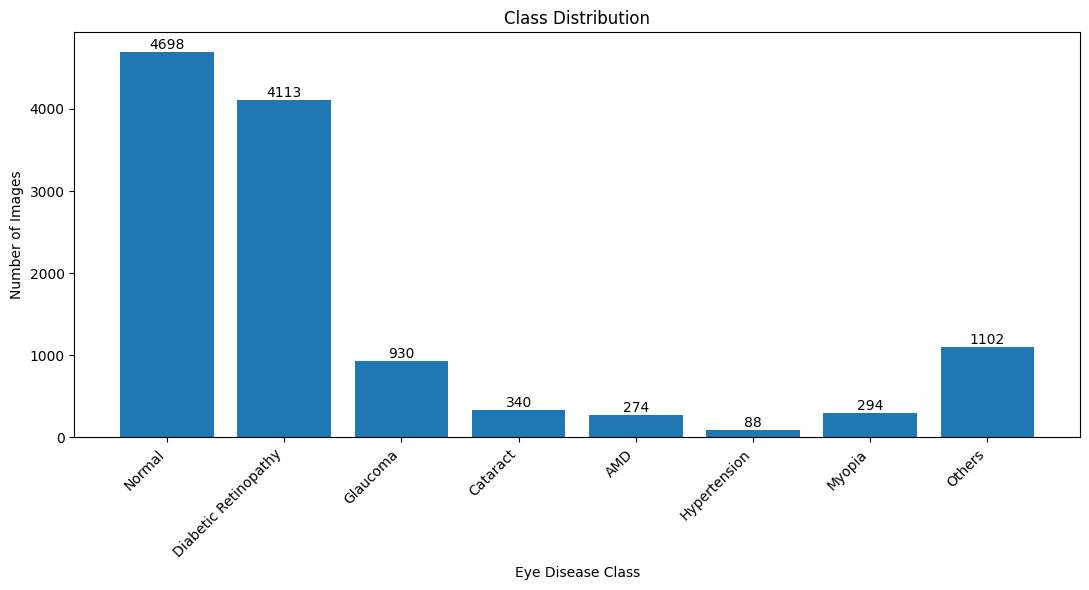

In [6]:
plt.figure(figsize=(11, 6))

bars = plt.bar(
    class_distribution_df["Class"],
    class_distribution_df["Count"]
)

plt.title("Class Distribution")
plt.xlabel("Eye Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")

for bar, count in zip(bars, class_distribution_df["Count"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [7]:
metadata["image_path"] = metadata[IMAGE_COL].apply(
    lambda x: IMAGES_DIR / str(x)
)

metadata["image_exists"] = metadata["image_path"].apply(
    lambda x: x.exists()
)

print(
    f"Images found: {metadata['image_exists'].sum():,} "
    f"/ {len(metadata):,}"
)

display(
    metadata[
        [IMAGE_COL, LABEL_COL, "image_path", "image_exists"]
    ].head()
)

Images found: 11,839 / 11,839


,filename,unified_label,image_path,image_exists
0,ACRIMA_Im001_ACRIMA.jpg,Normal,/kaggle/input/datasets/nebalelshobary/eye-dise...,True
1,ACRIMA_Im002_ACRIMA.jpg,Normal,/kaggle/input/datasets/nebalelshobary/eye-dise...,True
2,ACRIMA_Im003_ACRIMA.jpg,Normal,/kaggle/input/datasets/nebalelshobary/eye-dise...,True
3,ACRIMA_Im004_ACRIMA.jpg,Normal,/kaggle/input/datasets/nebalelshobary/eye-dise...,True
4,ACRIMA_Im005_ACRIMA.jpg,Normal,/kaggle/input/datasets/nebalelshobary/eye-dise...,True


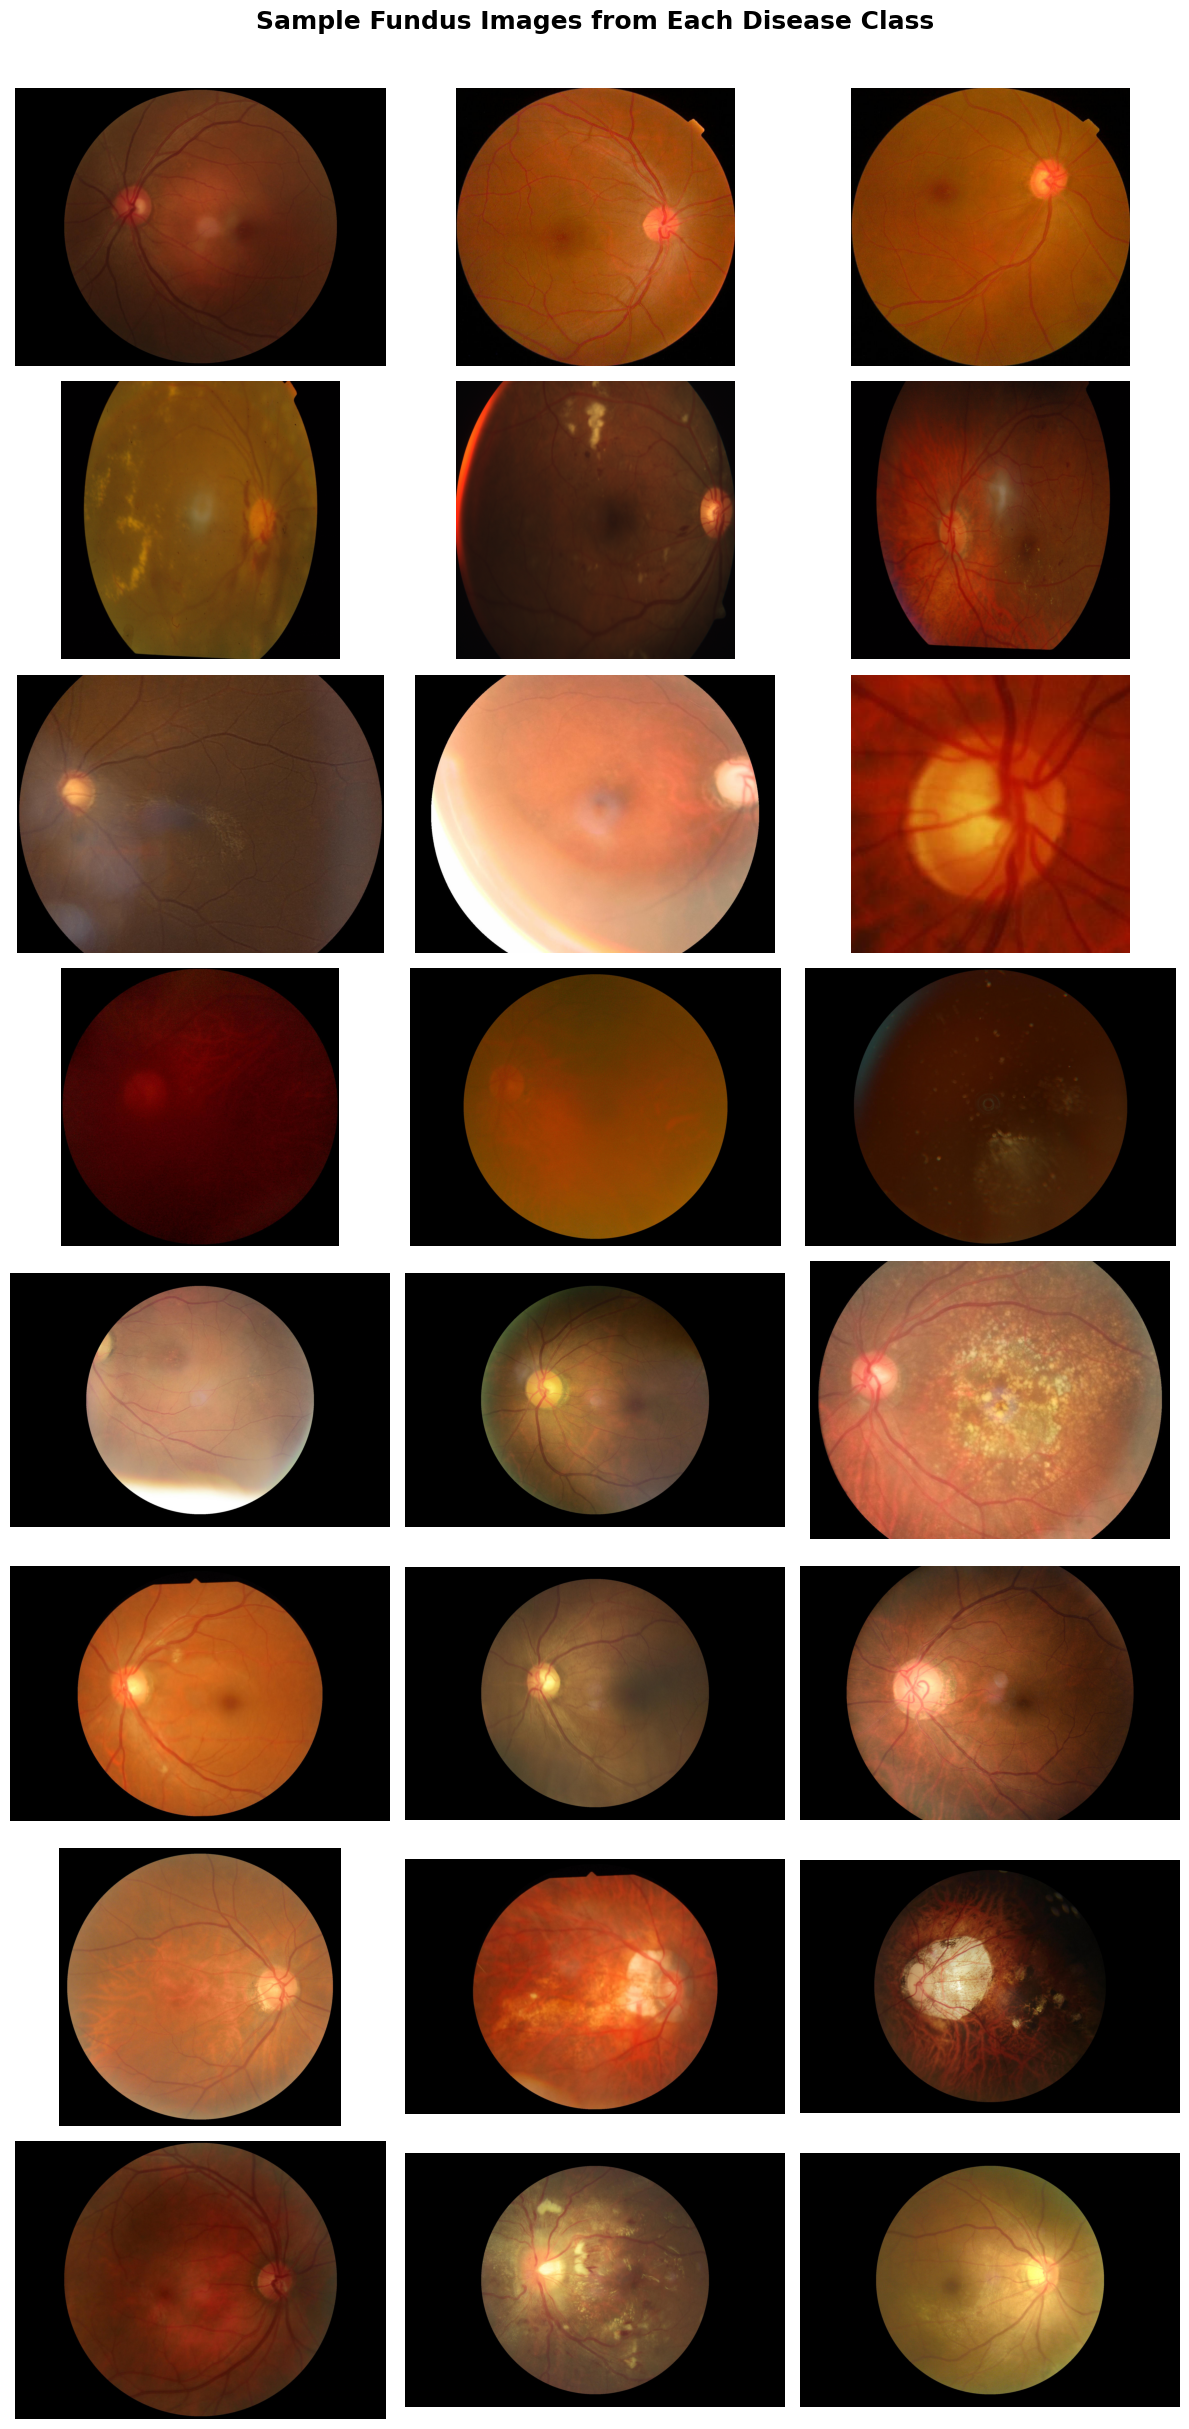

In [8]:
from PIL import Image
import matplotlib.pyplot as plt


N_SAMPLES = 3
RANDOM_STATE = 42

fig, axes = plt.subplots(
    nrows=len(CLASS_NAMES),
    ncols=N_SAMPLES,
    figsize=(12, 24)
)

for row, class_name in enumerate(CLASS_NAMES):

    class_samples = (
        metadata[
            (metadata[LABEL_COL] == class_name)
            & (metadata["image_exists"])
        ]
        .sample(
            n=min(
                N_SAMPLES,
                len(metadata[metadata[LABEL_COL] == class_name])
            ),
            random_state=RANDOM_STATE
        )
    )

    for col in range(N_SAMPLES):

        ax = axes[row, col]

        if col < len(class_samples):

            sample = class_samples.iloc[col]

            image = Image.open(
                sample["image_path"]
            ).convert("RGB")

            ax.imshow(image)

        ax.axis("off")

        if col == 0:
            ax.set_ylabel(
                class_name,
                fontsize=12,
                fontweight="bold",
                rotation=90,
                labelpad=15
            )

plt.suptitle(
    "Sample Fundus Images from Each Disease Class",
    fontsize=18,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

In [9]:
import re
import pandas as pd

from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold

SEED = 42

split_data = metadata[
    ["filename", "dataset", "unified_label", "original_label"]
].copy()

def get_group_id(row):

    filename = str(row["filename"])
    source = str(row["dataset"])

    if source == "ODIR5K":

        match = re.match(
            r"^ODIR_(\d+)_(left|right)\.jpg$",
            filename,
            flags=re.IGNORECASE
        )

        if match:
            return f"ODIR_patient_{match.group(1)}"

        raise ValueError(
            f"Cannot extract ODIR patient ID: {filename}"
        )

    elif source == "ACRIMA":

        match = re.match(
            r"^ACRIMA_Im(\d+)(?:_g)?_ACRIMA\.jpg$",
            filename,
            flags=re.IGNORECASE
        )

        if match:
            return f"ACRIMA_image_{match.group(1)}"

    return f"{source}_{filename}"


split_data["group_id"] = split_data.apply(
    get_group_id,
    axis=1
)

print("Total images:", len(split_data))
print("Total groups:", split_data["group_id"].nunique())

outer_splitter = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=SEED
)

train_val_idx, test_idx = next(
    outer_splitter.split(
        split_data,
        y=split_data["unified_label"],
        groups=split_data["group_id"]
    )
)

train_val_data = split_data.iloc[
    train_val_idx
].reset_index(drop=True)

test_new = split_data.iloc[
    test_idx
].reset_index(drop=True)

inner_splitter = StratifiedGroupKFold(
    n_splits=9,
    shuffle=True,
    random_state=SEED
)

train_idx, val_idx = next(
    inner_splitter.split(
        train_val_data,
        y=train_val_data["unified_label"],
        groups=train_val_data["group_id"]
    )
)

train_new = train_val_data.iloc[
    train_idx
].reset_index(drop=True)

val_new = train_val_data.iloc[
    val_idx
].reset_index(drop=True)

print("\n===== NEW SPLIT SIZES =====")

print("Train:", len(train_new))
print("Validation:", len(val_new))
print("Test:", len(test_new))
print("Total:", len(train_new) + len(val_new) + len(test_new))

Total images: 11839
Total groups: 8339

===== NEW SPLIT SIZES =====
Train: 9468
Validation: 1187
Test: 1184
Total: 11839


In [10]:
train_groups = set(train_new["group_id"])
val_groups = set(val_new["group_id"])
test_groups = set(test_new["group_id"])

print("===== GROUP LEAKAGE CHECK =====")

print("Train / Validation:", len(train_groups & val_groups))
print("Train / Test:", len(train_groups & test_groups))
print("Validation / Test:", len(val_groups & test_groups))

assert train_groups.isdisjoint(val_groups)
assert train_groups.isdisjoint(test_groups)
assert val_groups.isdisjoint(test_groups)

all_new = pd.concat(
    [train_new, val_new, test_new],
    ignore_index=True
)

assert len(all_new) == len(metadata)
assert all_new["filename"].is_unique
assert set(all_new["filename"]) == set(metadata["filename"])

new_distribution = pd.DataFrame({
    "Train": train_new["unified_label"].value_counts(),
    "Validation": val_new["unified_label"].value_counts(),
    "Test": test_new["unified_label"].value_counts()
}).reindex(CLASS_NAMES).fillna(0).astype(int)

display(new_distribution)

assert (new_distribution > 0).all().all(), (
    "At least one class is missing from a split."
)

NEW_SPLITS_DIR = OUTPUT_ROOT / "leakage_aware_splits"

NEW_SPLITS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

train_new.to_csv(
    NEW_SPLITS_DIR / "train.csv",
    index=False
)

val_new.to_csv(
    NEW_SPLITS_DIR / "val.csv",
    index=False
)

test_new.to_csv(
    NEW_SPLITS_DIR / "test.csv",
    index=False
)

print("\nNew splits validated and saved successfully!")

===== GROUP LEAKAGE CHECK =====
Train / Validation: 0
Train / Test: 0
Validation / Test: 0


,Train,Validation,Test
unified_label,,,
Normal,3760,466,472
Diabetic Retinopathy,3302,410,401
Glaucoma,740,87,103
Cataract,268,36,36
AMD,212,32,30
Hypertension,68,10,10
Myopia,240,28,26
Others,878,118,106



New splits validated and saved successfully!


In [11]:
train_df = train_new.copy()
val_df = val_new.copy()
test_df = test_new.copy()
assert all("group_id" in frame for frame in (train_df, val_df, test_df))
print("ACTIVE SPLITS: corrected group-aware", len(train_df), len(val_df), len(test_df))


ACTIVE SPLITS: corrected group-aware 9468 1187 1184


In [12]:
train_counts = train_df[LABEL_COL].value_counts()
val_counts   = val_df[LABEL_COL].value_counts()
test_counts  = test_df[LABEL_COL].value_counts()

split_distribution = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
}).fillna(0).astype(int)

split_distribution = split_distribution.reindex([
    "Normal",
    "Diabetic Retinopathy",
    "Glaucoma",
    "Cataract",
    "AMD",
    "Hypertension",
    "Myopia",
    "Others"
])

display(split_distribution)

,Train,Validation,Test
unified_label,,,
Normal,3760,466,472
Diabetic Retinopathy,3302,410,401
Glaucoma,740,87,103
Cataract,268,36,36
AMD,212,32,30
Hypertension,68,10,10
Myopia,240,28,26
Others,878,118,106


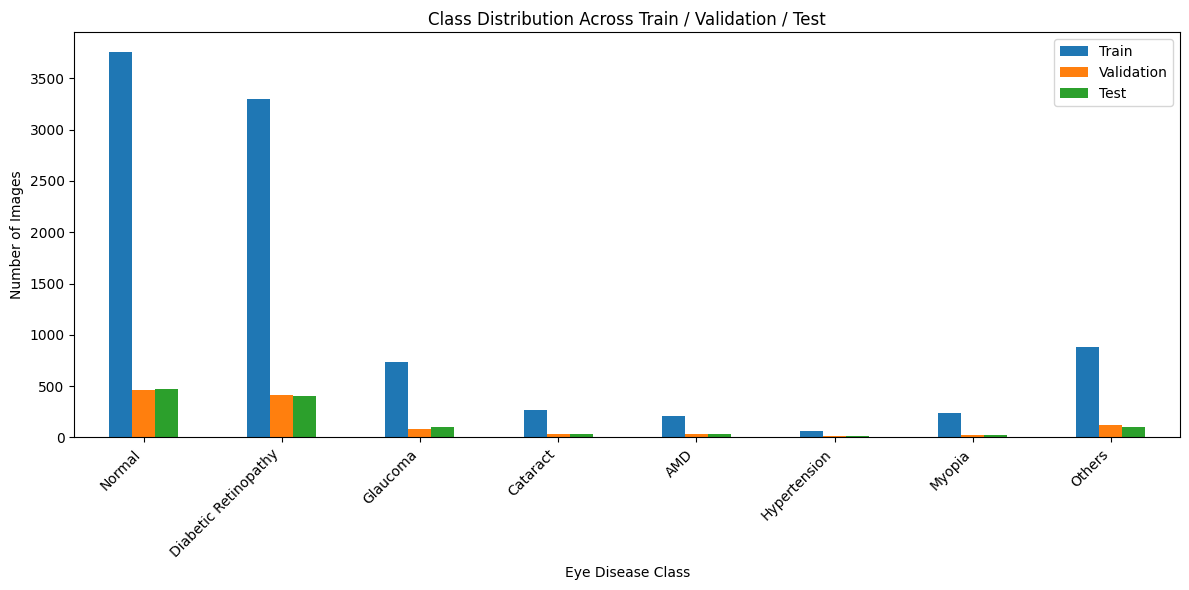

In [13]:
split_distribution.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Class Distribution Across Train / Validation / Test")
plt.xlabel("Eye Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [14]:
train_class_counts = (
    train_df[LABEL_COL]
    .value_counts()
    .reindex(CLASS_NAMES)
)

imbalance_df = train_class_counts.reset_index()
imbalance_df.columns = ["Class", "Train_Count"]

imbalance_df["Percentage"] = (
    imbalance_df["Train_Count"]
    / imbalance_df["Train_Count"].sum()
    * 100
).round(2)

display(imbalance_df)

,Class,Train_Count,Percentage
0,Normal,3760,39.71
1,Diabetic Retinopathy,3302,34.88
2,Glaucoma,740,7.82
3,Cataract,268,2.83
4,AMD,212,2.24
5,Hypertension,68,0.72
6,Myopia,240,2.53
7,Others,878,9.27


In [15]:
majority_class = imbalance_df.loc[
    imbalance_df["Train_Count"].idxmax()
]

minority_class = imbalance_df.loc[
    imbalance_df["Train_Count"].idxmin()
]

imbalance_ratio = (
    majority_class["Train_Count"]
    / minority_class["Train_Count"]
)

print("Majority class:", majority_class["Class"])
print("Majority samples:", majority_class["Train_Count"])

print("\nMinority class:", minority_class["Class"])
print("Minority samples:", minority_class["Train_Count"])

print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")

Majority class: Normal
Majority samples: 3760

Minority class: Hypertension
Minority samples: 68

Imbalance ratio: 55.29:1


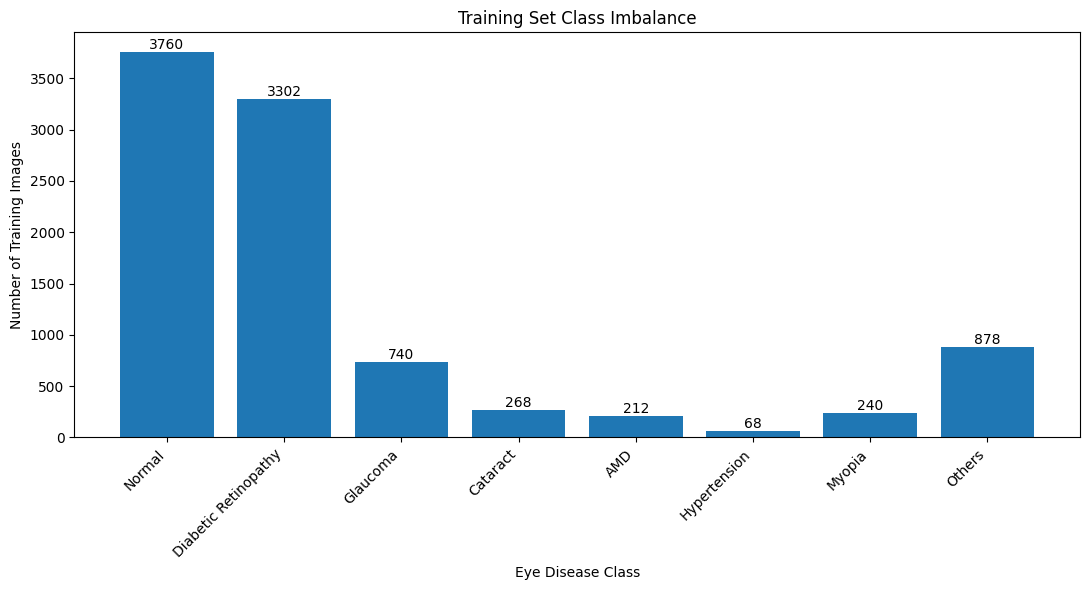

In [16]:
plt.figure(figsize=(11, 6))

bars = plt.bar(
    imbalance_df["Class"],
    imbalance_df["Train_Count"]
)

plt.title("Training Set Class Imbalance")
plt.xlabel("Eye Disease Class")
plt.ylabel("Number of Training Images")

plt.xticks(rotation=45, ha="right")

for bar, count in zip(
    bars,
    imbalance_df["Train_Count"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [17]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array(CLASS_NAMES)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df[LABEL_COL]
)

class_weights = {
    int(i): float(weight)
    for i, weight in enumerate(class_weights_array)
}

class_weights

{0: 0.3147606382978723,
 1: 0.3584191399152029,
 2: 1.5993243243243243,
 3: 4.416044776119403,
 4: 5.5825471698113205,
 5: 17.404411764705884,
 6: 4.93125,
 7: 1.3479498861047836}

In [18]:
class_weights_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Class_Index": range(len(CLASS_NAMES)),
    "Weight": class_weights_array
})

display(class_weights_df)

,Class,Class_Index,Weight
0,Normal,0,0.314761
1,Diabetic Retinopathy,1,0.358419
2,Glaucoma,2,1.599324
3,Cataract,3,4.416045
4,AMD,4,5.582547
5,Hypertension,5,17.404412
6,Myopia,6,4.931250
7,Others,7,1.347950


In [19]:
CLASS_TO_INDEX = {
    class_name: idx
    for idx, class_name in enumerate(CLASS_NAMES)
}

INDEX_TO_CLASS = {
    idx: class_name
    for class_name, idx in CLASS_TO_INDEX.items()
}

CLASS_TO_INDEX

{'Normal': 0,
 'Diabetic Retinopathy': 1,
 'Glaucoma': 2,
 'Cataract': 3,
 'AMD': 4,
 'Hypertension': 5,
 'Myopia': 6,
 'Others': 7}

In [20]:
train_df["label"] = train_df[LABEL_COL].map(CLASS_TO_INDEX)
val_df["label"]   = val_df[LABEL_COL].map(CLASS_TO_INDEX)
test_df["label"]  = test_df[LABEL_COL].map(CLASS_TO_INDEX)

display(
    train_df[
        [LABEL_COL, "label"]
    ].head()
)

,unified_label,label
0,Normal,0
1,Normal,0
2,Normal,0
3,Normal,0
4,Normal,0


In [21]:
assert train_df["label"].isnull().sum() == 0
assert val_df["label"].isnull().sum() == 0
assert test_df["label"].isnull().sum() == 0

print("All labels encoded successfully.")

All labels encoded successfully.


In [22]:
print("===== IMBALANCE STRATEGY =====")

print(
    f"Majority class: {majority_class['Class']} "
    f"({majority_class['Train_Count']} samples)"
)

print(
    f"Minority class: {minority_class['Class']} "
    f"({minority_class['Train_Count']} samples)"
)

print(
    f"Imbalance ratio: {imbalance_ratio:.2f}:1"
)

print(
    "\nSelected strategy: "
    "Class-weighted training."
)

print(
    "Higher loss weights will be assigned to minority classes "
    "during model training."
)

===== IMBALANCE STRATEGY =====
Majority class: Normal (3760 samples)
Minority class: Hypertension (68 samples)
Imbalance ratio: 55.29:1

Selected strategy: Class-weighted training.
Higher loss weights will be assigned to minority classes during model training.


In [23]:
for split_name, frame in (("train", train_df), ("val", val_df), ("test", test_df)):
    assert frame["label"].notna().all()
    missing = [n for n in frame[IMAGE_COL].astype(str) if not (IMAGES_DIR / n).is_file()]
    assert not missing, f"{split_name}: missing images; first={missing[:3]}"
print("All split images exist. Split groups are disjoint.")


All split images exist. Split groups are disjoint.


In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

NUM_CLASSES = len(CLASS_NAMES)

print("Number of classes:", NUM_CLASSES)

Number of classes: 8


In [25]:

for df in [train_df, val_df, test_df]:
    df["image_path"] = df[IMAGE_COL].apply(
        lambda x: str(IMAGES_DIR / str(x))
    )

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 9468
Validation: 1187
Test: 1184


In [26]:
def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

In [27]:
def create_dataset(
    dataframe,
    training=False
):

    image_paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [28]:
train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df,
    training=False
)

test_ds = create_dataset(
    test_df,
    training=False
)

I0000 00:00:1790325631.289375    1095 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790325631.291555    1095 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [29]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal"
        ),

        layers.RandomRotation(
            0.05
        ),

        layers.RandomZoom(
            0.10
        ),

        layers.RandomContrast(
            0.10
        ),
    ],
    name="data_augmentation"
)

In [30]:
def build_scratch_cnn(
    input_shape=(224, 224, 3),
    num_classes=8
):

    inputs = keras.Input(
        shape=input_shape
    )

    # Augmentation
    x = data_augmentation(inputs)

    # Normalize pixels to [0, 1]
    x = layers.Rescaling(
        1.0 / 255
    )(x)


    # Block 1
    x = layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D()(x)


    # Block 2
    x = layers.Conv2D(
        64,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D()(x)


    # Block 3
    x = layers.Conv2D(
        128,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D()(x)


    # Block 4
    x = layers.Conv2D(
        256,
        kernel_size=3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D()(x)


    # Classification head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        256,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.4
    )(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="predictions"
    )(x)


    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="Scratch_CNN"
    )

    return model

In [31]:
# STEP 4 - TRAIN SCRATCH CNN

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger
)

SEED = 42
EPOCHS = 30

tf.keras.utils.set_random_seed(SEED)

CORRECTED_OUTPUT_ROOT = OUTPUT_ROOT / "leakage_aware"
CORRECTED_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = CORRECTED_OUTPUT_ROOT / "scratch_cnn"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = OUTPUT_DIR / "scratch_cnn_best.keras"
HISTORY_PATH = OUTPUT_DIR / "training_log.csv"

In [32]:
scratch_model = build_scratch_cnn(
    input_shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    ),
    num_classes=NUM_CLASSES
)

In [33]:
scratch_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

In [34]:
scratch_model.summary()

Model: "Scratch_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,184 (1.75 MB)

 Trainable params: 457,224 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [35]:
scratch_callbacks = [
    ModelCheckpoint(
        filepath=str(CHECKPOINT_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    CSVLogger(
        filename=str(HISTORY_PATH)
    )
]

## Train scratch CNN on corrected splits
The best epoch is selected on the corrected validation set. The corrected test set stays untouched until both model-training stages finish.

In [36]:
scratch_history = scratch_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=scratch_callbacks,
    verbose=1
)

Epoch 1/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.2324 - loss: 2.0142
Epoch 1: val_loss improved from None to 1.65000, saving model to /kaggle/working/outputs/leakage_aware/scratch_cnn/scratch_cnn_best.keras

Epoch 1: finished saving model to /kaggle/working/outputs/leakage_aware/scratch_cnn/scratch_cnn_best.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 71s 209ms/step - accuracy: 0.2465 - loss: 1.9221 - val_accuracy: 0.4027 - val_loss: 1.6500 - learning_rate: 0.0010
Epoch 2/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.2622 - loss: 1.8317
Epoch 2: val_loss did not improve from 1.65000
296/296 ━━━━━━━━━━━━━━━━━━━━ 62s 209ms/step - accuracy: 0.2788 - loss: 1.7511 - val_accuracy: 0.2898 - val_loss: 1.7217 - learning_rate: 0.0010
Epoch 3/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.2884 - loss: 1.6915
Epoch 3: val_loss did not improve from 1.65000
296/296 ━━━━━━━━━━━━━━━━━━━━ 62s 208ms/step - accuracy: 0.3041 - loss: 1.6926 - val_accuracy: 0.2308 - val_l

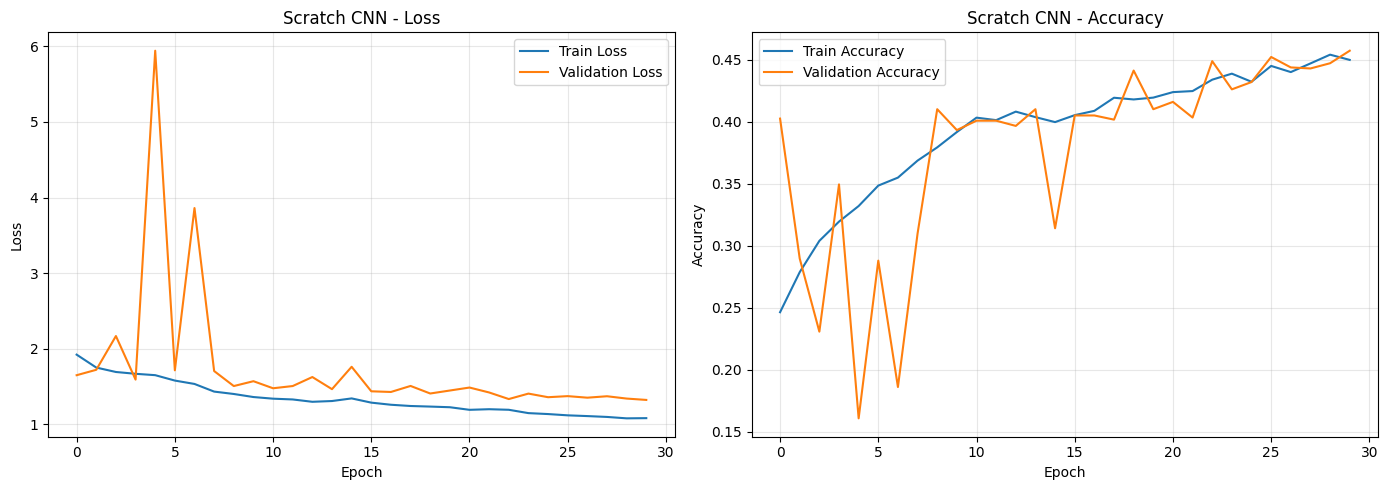

In [37]:
# Training history
history_df = pd.DataFrame(scratch_history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["loss"], label="Train Loss")
axes[0].plot(history_df["val_loss"], label="Validation Loss")
axes[0].set_title("Scratch CNN - Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["accuracy"], label="Train Accuracy")
axes[1].plot(history_df["val_accuracy"], label="Validation Accuracy")
axes[1].set_title("Scratch CNN - Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "training_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
# STEP 6 - PRETRAINED RESNET50

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

RESNET_OUTPUT_DIR = CORRECTED_OUTPUT_ROOT / "resnet50"
RESNET_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tf.keras.utils.set_random_seed(42)

# Load pretrained ResNet50 without its original classification head
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained backbone
resnet_base.trainable = False

# Build classification model
inputs = keras.Input(shape=(224, 224, 3))

# Apply the same augmentation strategy
x = keras.models.clone_model(data_augmentation)(inputs)

# ResNet50-specific preprocessing
x = preprocess_input(x)

# Pretrained feature extractor
x = resnet_base(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="predictions"
)(x)

resnet_model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="ResNet50_EyeDisease"
)

resnet_model.summary()

Model: "ResNet50_EyeDisease"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 8)         │      2,056 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,114,312 (91.99 MB)

 Trainable params: 526,600 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [39]:
# Compile model for classification head training

resnet_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("ResNet50 compiled successfully.")

ResNet50 compiled successfully.


In [40]:
# STEP 6.1 - RESNET50 HEAD TRAINING

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger
)

HEAD_EPOCHS = 15

RESNET_HEAD_CHECKPOINT = (
    RESNET_OUTPUT_DIR / "resnet50_head_best.keras"
)

RESNET_HEAD_LOG = (
    RESNET_OUTPUT_DIR / "resnet50_head_training.csv"
)

resnet_head_callbacks = [
    ModelCheckpoint(
        filepath=str(RESNET_HEAD_CHECKPOINT),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    CSVLogger(
        filename=str(RESNET_HEAD_LOG)
    )
]

In [41]:
resnet_head_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    class_weight=class_weights,
    callbacks=resnet_head_callbacks,
    verbose=1
)

Epoch 1/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.3544 - loss: 1.8548
Epoch 1: val_loss improved from None to 1.52840, saving model to /kaggle/working/outputs/leakage_aware/resnet50/resnet50_head_best.keras

Epoch 1: finished saving model to /kaggle/working/outputs/leakage_aware/resnet50/resnet50_head_best.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 75s 227ms/step - accuracy: 0.4058 - loss: 1.5506 - val_accuracy: 0.4111 - val_loss: 1.5284 - learning_rate: 0.0010
Epoch 2/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.4420 - loss: 1.3459
Epoch 2: val_loss improved from 1.52840 to 1.47403, saving model to /kaggle/working/outputs/leakage_aware/resnet50/resnet50_head_best.keras

Epoch 2: finished saving model to /kaggle/working/outputs/leakage_aware/resnet50/resnet50_head_best.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 64s 215ms/step - accuracy: 0.4532 - loss: 1.3078 - val_accuracy: 0.4313 - val_loss: 1.4740 - learning_rate: 0.0010
Epoch 3/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 18

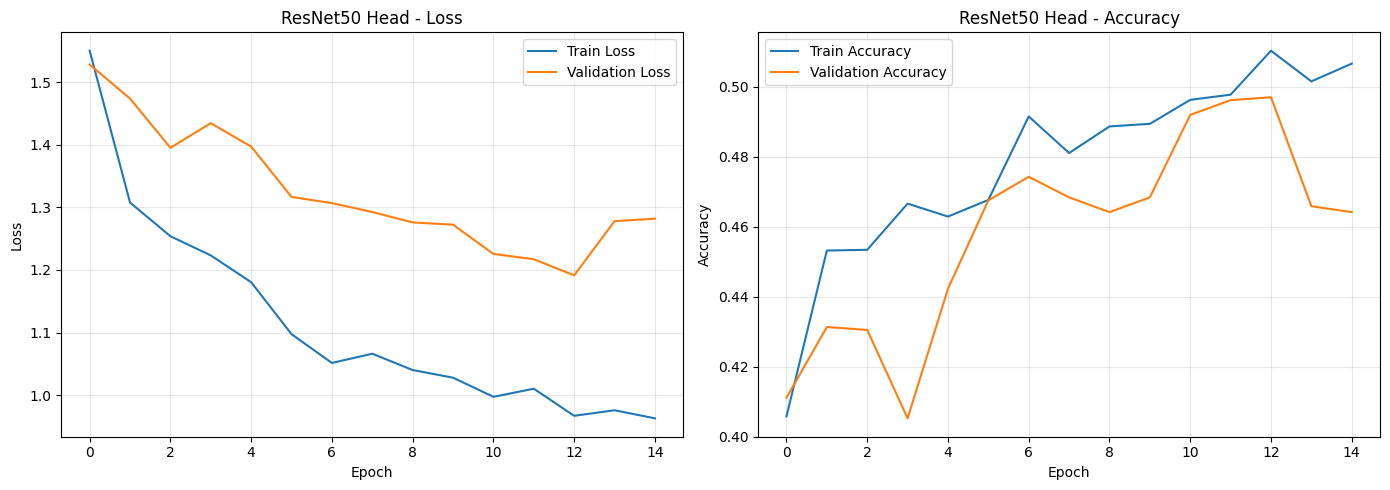

In [ ]:
head_history_df = pd.DataFrame(
    resnet_head_history.history
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    head_history_df["loss"],
    label="Train Loss"
)
axes[0].plot(
    head_history_df["val_loss"],
    label="Validation Loss"
)
axes[0].set_title("ResNet50 Head - Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    head_history_df["accuracy"],
    label="Train Accuracy"
)
axes[1].plot(
    head_history_df["val_accuracy"],
    label="Validation Accuracy"
)
axes[1].set_title("ResNet50 Head - Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    RESNET_OUTPUT_DIR / "head_training_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger
)

best_head_model = keras.models.load_model(
    str(RESNET_HEAD_CHECKPOINT)
)

resnet_base = best_head_model.get_layer("resnet50")

resnet_base.trainable = True

for layer in resnet_base.layers[:-30]:
    layer.trainable = False

for layer in resnet_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(
    "Trainable backbone layers:",
    sum(layer.trainable for layer in resnet_base.layers)
)

best_head_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

FINE_TUNE_EPOCHS = 15

RESNET_FINE_TUNED_CHECKPOINT = (
    RESNET_OUTPUT_DIR / "resnet50_finetuned_best.keras"
)

RESNET_FINE_TUNE_LOG = (
    RESNET_OUTPUT_DIR / "resnet50_finetuning.csv"
)

fine_tune_callbacks = [
    ModelCheckpoint(
        filepath=str(RESNET_FINE_TUNED_CHECKPOINT),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    CSVLogger(
        filename=str(RESNET_FINE_TUNE_LOG)
    )
]

resnet_finetune_history = best_head_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks,
    verbose=1
)

Trainable backbone layers: 21
Epoch 1/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.5054 - loss: 0.9655
Epoch 1: val_loss improved from None to 1.33165, saving model to /kaggle/working/outputs/leakage_aware/resnet50/resnet50_finetuned_best.keras

Epoch 1: finished saving model to /kaggle/working/outputs/leakage_aware/resnet50/resnet50_finetuned_best.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 79s 233ms/step - accuracy: 0.5086 - loss: 0.9677 - val_accuracy: 0.4583 - val_loss: 1.3316 - learning_rate: 1.0000e-05
Epoch 2/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.5326 - loss: 0.8788
Epoch 2: val_loss improved from 1.33165 to 1.22643, saving model to /kaggle/working/outputs/leakage_aware/resnet50/resnet50_finetuned_best.keras

Epoch 2: finished saving model to /kaggle/working/outputs/leakage_aware/resnet50/resnet50_finetuned_best.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 66s 223ms/step - accuracy: 0.5224 - loss: 0.9106 - val_accuracy: 0.4600 - val_loss: 1.2264 - learning_rate

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

best_scratch_model = keras.models.load_model(
    str(CHECKPOINT_PATH)
)

scratch_test_loss, scratch_test_accuracy = best_scratch_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Loss: {scratch_test_loss:.4f}")
print(f"Test Accuracy: {scratch_test_accuracy:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 194ms/step - accuracy: 0.4502 - loss: 1.3481
Test Loss: 1.3481
Test Accuracy: 0.4502


In [ ]:
y_true = test_df["label"].to_numpy(dtype=int)

# Model predictions
y_prob = best_scratch_model.predict(
    test_ds,
    verbose=1
)

y_pred = np.argmax(y_prob, axis=1)

assert len(y_true) == len(y_pred), "Prediction count mismatch"

scratch_report = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

scratch_report_df = pd.DataFrame(
    scratch_report
).transpose()

display(scratch_report_df.round(4))

scratch_report_df.to_csv(
    OUTPUT_DIR / "classification_report.csv"
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 182ms/step


,precision,recall,f1-score,support
Normal,0.8131,0.4979,0.6176,472.0000
Diabetic Retinopathy,0.9130,0.4190,0.5744,401.0000
Glaucoma,0.5111,0.4466,0.4767,103.0000
Cataract,0.4032,0.6944,0.5102,36.0000
AMD,0.0473,0.2667,0.0804,30.0000
Hypertension,0.0103,0.2000,0.0196,10.0000
Myopia,0.5000,0.7692,0.6061,26.0000
Others,0.1859,0.2736,0.2214,106.0000
accuracy,0.4502,0.4502,0.4502,0.4502
macro avg,0.4230,0.4459,0.3883,1184.0000


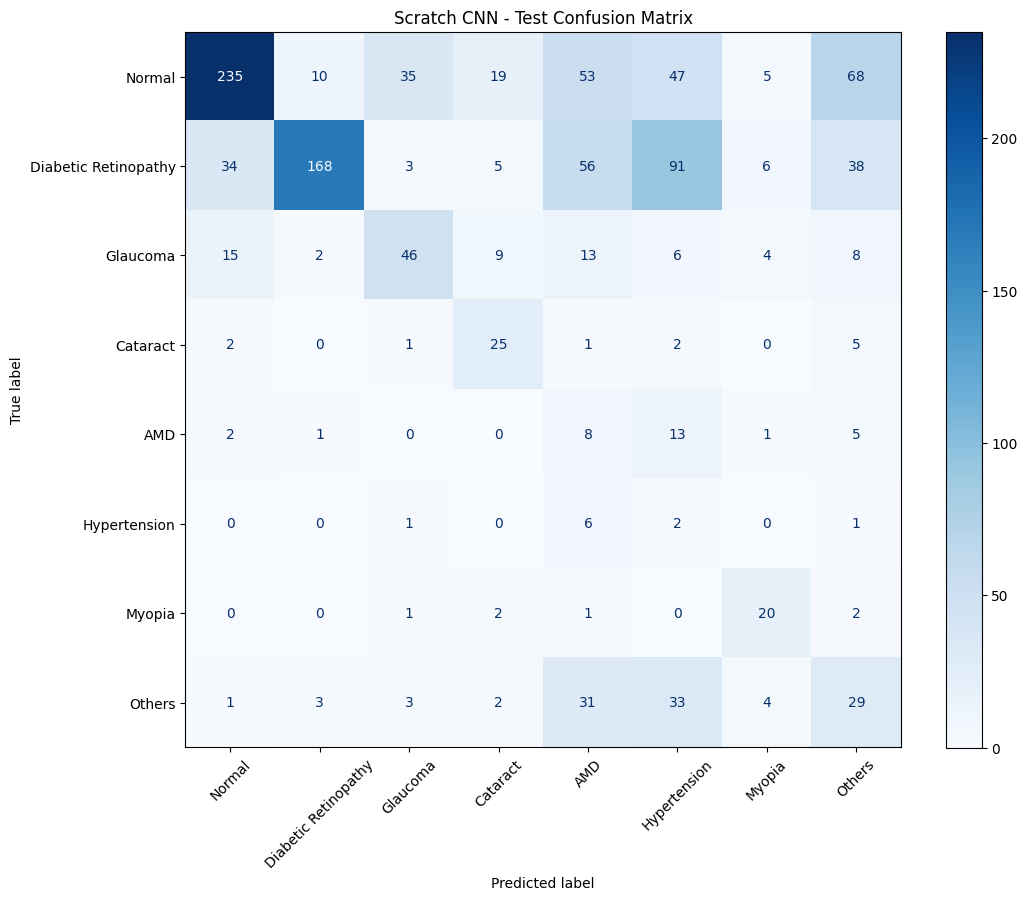

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)

fig, ax = plt.subplots(figsize=(11, 9))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
).plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Scratch CNN - Test Confusion Matrix")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

best_resnet_model = keras.models.load_model(
    str(RESNET_FINE_TUNED_CHECKPOINT)
)

print("Best fine-tuned ResNet50 loaded successfully.")

resnet_test_loss, resnet_test_accuracy = best_resnet_model.evaluate(
    test_ds,
    verbose=1
)

print(f"\nResNet50 Test Loss: {resnet_test_loss:.4f}")
print(f"ResNet50 Test Accuracy: {resnet_test_accuracy:.4f}")

Best fine-tuned ResNet50 loaded successfully.
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step - accuracy: 0.5068 - loss: 1.1890

ResNet50 Test Loss: 1.1890
ResNet50 Test Accuracy: 0.5068


In [ ]:

resnet_y_true = test_df["label"].to_numpy(dtype=int)

resnet_y_prob = best_resnet_model.predict(
    test_ds,
    verbose=1
)

resnet_y_pred = np.argmax(
    resnet_y_prob,
    axis=1
)

assert len(resnet_y_true) == len(resnet_y_pred)

resnet_report = classification_report(
    resnet_y_true,
    resnet_y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

resnet_report_df = pd.DataFrame(
    resnet_report
).transpose()

display(resnet_report_df.round(4))

resnet_report_df.to_csv(
    RESNET_OUTPUT_DIR / "classification_report.csv"
)

print("ResNet50 classification report saved successfully.")


37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 195ms/step


,precision,recall,f1-score,support
Normal,0.8566,0.5191,0.6464,472.0000
Diabetic Retinopathy,0.9427,0.4514,0.6105,401.0000
Glaucoma,0.4790,0.5534,0.5135,103.0000
Cataract,0.4138,0.6667,0.5106,36.0000
AMD,0.1129,0.2333,0.1522,30.0000
Hypertension,0.0133,0.1000,0.0235,10.0000
Myopia,0.6061,0.7692,0.6780,26.0000
Others,0.1811,0.6132,0.2796,106.0000
accuracy,0.5068,0.5068,0.5068,0.5068
macro avg,0.4507,0.4883,0.4268,1184.0000


ResNet50 classification report saved successfully.


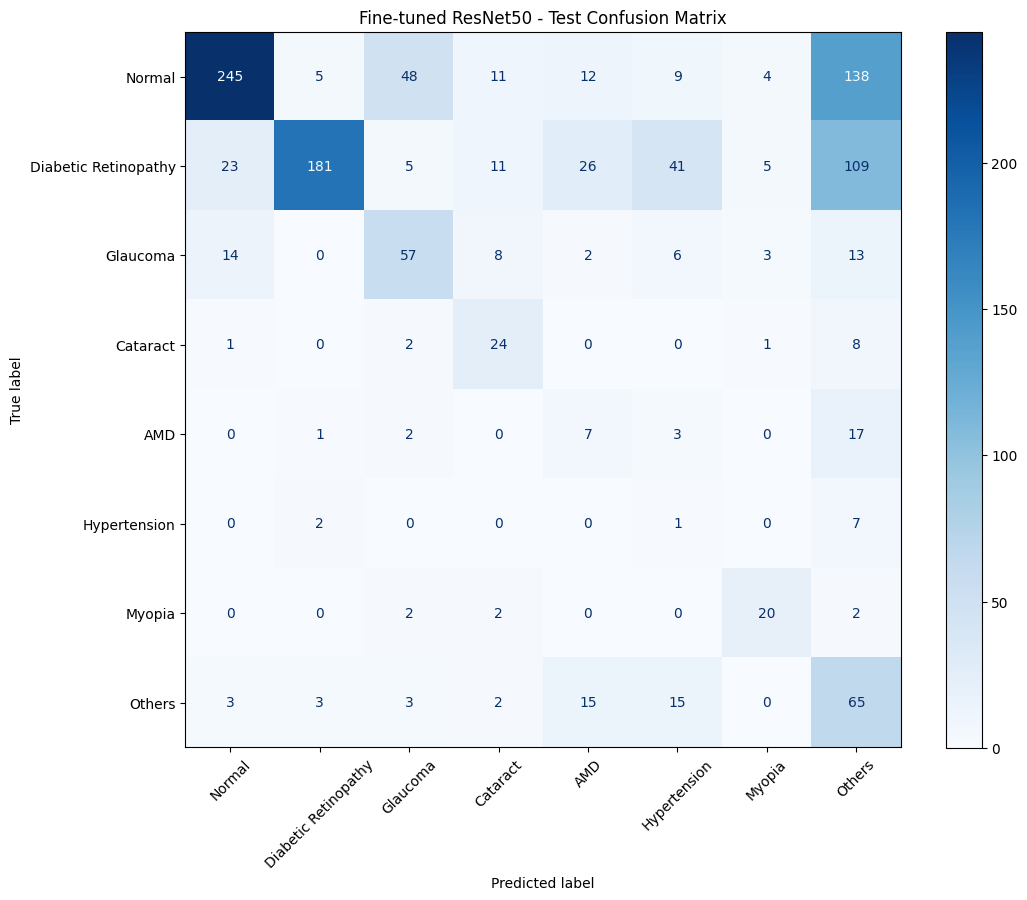

In [ ]:
resnet_cm = confusion_matrix(
    resnet_y_true,
    resnet_y_pred,
    labels=list(range(NUM_CLASSES))
)

fig, ax = plt.subplots(figsize=(11, 9))

ConfusionMatrixDisplay(
    confusion_matrix=resnet_cm,
    display_labels=CLASS_NAMES
).plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("Fine-tuned ResNet50 - Test Confusion Matrix")

plt.tight_layout()

plt.savefig(
    RESNET_OUTPUT_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

import pandas as pd
import matplotlib.pyplot as plt

scratch_report_df = pd.read_csv(
    OUTPUT_DIR / "classification_report.csv",
    index_col=0
)

resnet_report_df = pd.read_csv(
    RESNET_OUTPUT_DIR / "classification_report.csv",
    index_col=0
)

comparison_df = pd.DataFrame({
    "Model": [
        "Scratch CNN",
        "Fine-tuned ResNet50"
    ],

    "Test Accuracy": [
        scratch_test_accuracy,
        resnet_test_accuracy
    ],

    "Macro F1": [
        scratch_report_df.loc["macro avg", "f1-score"],
        resnet_report_df.loc["macro avg", "f1-score"]
    ],

    "Weighted F1": [
        scratch_report_df.loc["weighted avg", "f1-score"],
        resnet_report_df.loc["weighted avg", "f1-score"]
    ]
})

display(comparison_df.round(4))

comparison_df.to_csv(
    OUTPUT_ROOT / "model_comparison.csv",
    index=False
)

,Model,Test Accuracy,Macro F1,Weighted F1
0,Scratch CNN,0.4502,0.3883,0.5330
1,Fine-tuned ResNet50,0.5068,0.4268,0.5686


,Class,Scratch CNN Recall,ResNet50 Recall,Scratch CNN F1,ResNet50 F1
0,Normal,0.4979,0.5191,0.6176,0.6464
1,Diabetic Retinopathy,0.4190,0.4514,0.5744,0.6105
2,Glaucoma,0.4466,0.5534,0.4767,0.5135
3,Cataract,0.6944,0.6667,0.5102,0.5106
4,AMD,0.2667,0.2333,0.0804,0.1522
5,Hypertension,0.2000,0.1000,0.0196,0.0235
6,Myopia,0.7692,0.7692,0.6061,0.6780
7,Others,0.2736,0.6132,0.2214,0.2796


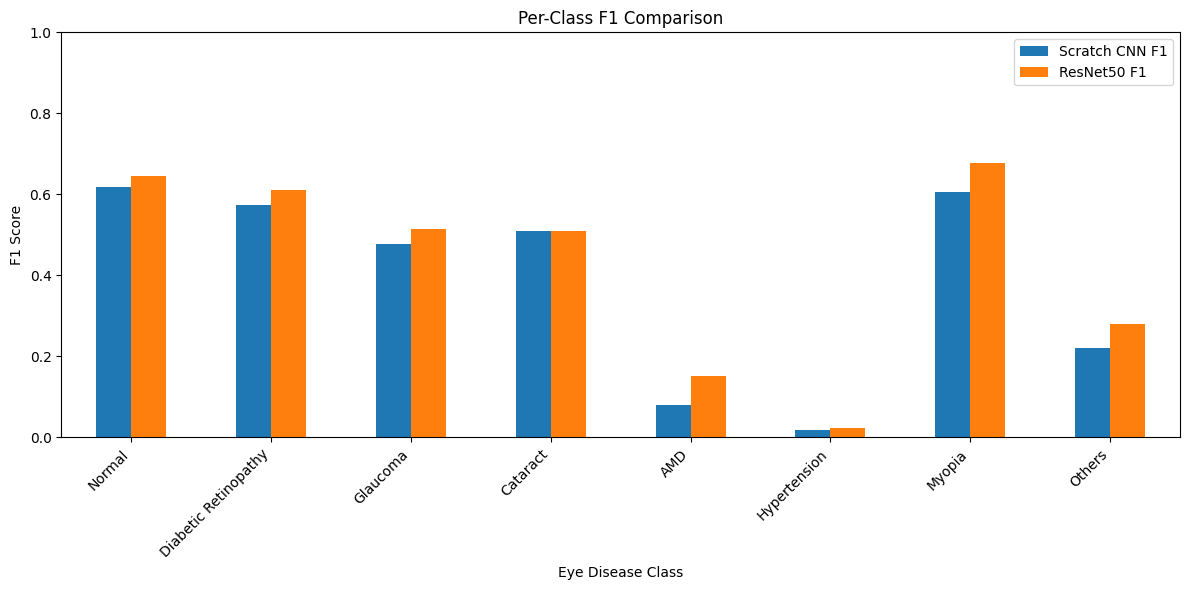

In [ ]:
per_class_comparison = pd.DataFrame({
    "Class": CLASS_NAMES,

    "Scratch CNN Recall": [
        scratch_report_df.loc[c, "recall"]
        for c in CLASS_NAMES
    ],

    "ResNet50 Recall": [
        resnet_report_df.loc[c, "recall"]
        for c in CLASS_NAMES
    ],

    "Scratch CNN F1": [
        scratch_report_df.loc[c, "f1-score"]
        for c in CLASS_NAMES
    ],

    "ResNet50 F1": [
        resnet_report_df.loc[c, "f1-score"]
        for c in CLASS_NAMES
    ]
})

display(per_class_comparison.round(4))

per_class_comparison.to_csv(
    OUTPUT_ROOT / "per_class_comparison.csv",
    index=False
)

ax = per_class_comparison.set_index("Class")[
    ["Scratch CNN F1", "ResNet50 F1"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Per-Class F1 Comparison")
ax.set_xlabel("Eye Disease Class")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1)

plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_ROOT / "per_class_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import time
import numpy as np
import tensorflow as tf
import pandas as pd

benchmark_images, _ = next(iter(test_ds))

WARMUP_RUNS = 5
BENCHMARK_RUNS = 30

def benchmark_model(model, images, warmup=5, runs=30):

    for _ in range(warmup):
        predictions = model(images, training=False)
        _ = predictions.numpy()

    timings = []

    for _ in range(runs):

        start = time.perf_counter()

        predictions = model(images, training=False)

        _ = predictions.numpy()

        elapsed = time.perf_counter() - start

        timings.append(elapsed)

    batch_size = int(images.shape[0])

    return {
        "Batch Size": batch_size,
        "Mean Batch Latency (ms)": np.mean(timings) * 1000,
        "Median Batch Latency (ms)": np.median(timings) * 1000,
        "Throughput (images/sec)": batch_size / np.mean(timings)
    }


scratch_speed = benchmark_model(
    best_scratch_model,
    benchmark_images,
    WARMUP_RUNS,
    BENCHMARK_RUNS
)

resnet_speed = benchmark_model(
    best_resnet_model,
    benchmark_images,
    WARMUP_RUNS,
    BENCHMARK_RUNS
)

speed_df = pd.DataFrame(
    [
        {"Model": "Scratch CNN", **scratch_speed},
        {"Model": "Fine-tuned ResNet50", **resnet_speed}
    ]
)

display(speed_df.round(2))

,Model,Batch Size,Mean Batch Latency (ms),Median Batch Latency (ms),Throughput (images/sec)
0,Scratch CNN,32,35.43,35.33,903.10
1,Fine-tuned ResNet50,32,211.77,210.68,151.11


In [ ]:
from pathlib import Path

model_paths = {
    "Scratch CNN": Path(CHECKPOINT_PATH),
    "Fine-tuned ResNet50": Path(RESNET_FINE_TUNED_CHECKPOINT)
}

model_sizes = []

for model_name, model_path in model_paths.items():

    assert model_path.exists(), (
        f"Checkpoint not found: {model_path}"
    )

    size_mb = model_path.stat().st_size / (1024 ** 2)

    model_sizes.append({
        "Model": model_name,
        "Parameters": (
            best_scratch_model.count_params()
            if model_name == "Scratch CNN"
            else best_resnet_model.count_params()
        ),
        "Checkpoint Size (MB)": size_mb
    })

size_df = pd.DataFrame(model_sizes)

display(size_df.round(2))

,Model,Parameters,Checkpoint Size (MB)
0,Scratch CNN,458184,5.33
1,Fine-tuned ResNet50,24114312,206.74


In [ ]:
final_comparison = (
    comparison_df
    .merge(speed_df, on="Model")
    .merge(size_df, on="Model")
)

display(final_comparison.round(4))

final_comparison.to_csv(
    OUTPUT_ROOT / "final_model_comparison.csv",
    index=False
)

print("Final model comparison saved successfully.")

,Model,Test Accuracy,Macro F1,Weighted F1,Batch Size,Mean Batch Latency (ms),Median Batch Latency (ms),Throughput (images/sec),Parameters,Checkpoint Size (MB)
0,Scratch CNN,0.4502,0.3883,0.5330,32,35.4336,35.3342,903.0980,458184,5.3313
1,Fine-tuned ResNet50,0.5068,0.4268,0.5686,32,211.7701,210.6820,151.1073,24114312,206.7428


Final model comparison saved successfully.


In [ ]:
import hashlib, json, platform
split_hashes = {}
for name, frame in (("train", train_df), ("val", val_df), ("test", test_df)):
    canonical = "\n".join(sorted(frame[IMAGE_COL].astype(str)))
    split_hashes[name] = hashlib.sha256(canonical.encode()).hexdigest()
experiment_manifest = {
    "dataset": "nebalelshobary/eye-disease-classification-dataset",
    "experiment": "leakage_aware_group_split_seed42",
    "seed": SEED, "split_sizes": {"train":len(train_df), "val":len(val_df), "test":len(test_df)},
    "split_sha256": split_hashes,
    "classes": CLASS_NAMES, "image_size": list(IMG_SIZE), "batch_size": BATCH_SIZE,
    "epochs_max": {"scratch": EPOCHS, "resnet_head": HEAD_EPOCHS, "resnet_finetune": FINE_TUNE_EPOCHS},
    "test_metrics": final_comparison.to_dict(orient="records"),
    "patient_grouping": "ODIR patient number from left/right filename; ACRIMA Im number conservatively grouped; APTOS2019 and ORIGA image-level only",
    "limitations": ["No validated patient IDs for APTOS2019 or ORIGA", "Only 88 Hypertension images overall; uncertainty is high", "Batch inference timing excludes file IO; not a single-image real-time benchmark", "Research use only; not a clinically validated diagnostic system"],
    "python": platform.python_version(), "tensorflow": tf.__version__
}
manifest_path = CORRECTED_OUTPUT_ROOT / "experiment_manifest.json"
manifest_path.write_text(json.dumps(experiment_manifest, indent=2, default=float), encoding="utf-8")
print("Manifest saved:", manifest_path)


Manifest saved: /kaggle/working/outputs/leakage_aware/experiment_manifest.json


In [ ]:
single_image = benchmark_images[:1]
single_speed_df = pd.DataFrame([
    {"Model": "Scratch CNN", **benchmark_model(best_scratch_model, single_image, warmup=5, runs=30)},
    {"Model": "Fine-tuned ResNet50", **benchmark_model(best_resnet_model, single_image, warmup=5, runs=30)}
])
display(single_speed_df.round(3))
single_speed_df.to_csv(CORRECTED_OUTPUT_ROOT / "single_image_latency.csv", index=False)


,Model,Batch Size,Mean Batch Latency (ms),Median Batch Latency (ms),Throughput (images/sec)
0,Scratch CNN,1,19.052,18.960,52.487
1,Fine-tuned ResNet50,1,209.890,209.698,4.764


In [ ]:
readme = f"""# Eye Disease Classification — Leakage-aware Kaggle Experiment

Dataset: 11,839 fundus images, 8 classes (ODIR5K, APTOS2019, ACRIMA, ORIGA). Run this notebook in Kaggle with the attached dataset and GPU.

## Method
- Group-aware split (seed {SEED}): train {len(train_df)}, validation {len(val_df)}, test {len(test_df)}.
- ODIR left/right images for the same patient are always assigned to the same split. ACRIMA Im identifiers are conservatively grouped. APTOS2019 and ORIGA lack verified patient identifiers.
- Class weighting calculated only on the corrected training split. Scratch CNN trained from scratch; ImageNet ResNet50 head training then fine-tuning of late backbone layers. Same corrected splits and class mapping for both.
- Best checkpoints chosen by validation loss. Test set used only for final evaluation after both models are fixed.

## Results (corrected split; do not mix with earlier image-level results)
{final_comparison.to_markdown(index=False, floatfmt='.4f')}

Per-class performance: `scratch_cnn/classification_report.csv`, `resnet50/classification_report.csv`, and `per_class_comparison.csv`. Confusion matrices and training curves are in model directories. Single-image latency: `single_image_latency.csv`.

## Deployment interpretation
Benchmark latency is measured on this Kaggle session's GPU. Batch-32 inference excludes disk reads and external preprocessing; the separate batch-1 benchmark is also provided. Checkpoint size includes Keras serialization and possible optimizer state, not only deployed weight size. Compare accuracy, per-class F1/recall, latency and footprint together; neither model is clinically validated.

## Known limitations
- ODIR group overlap was found in the original provided split, so original test scores should not be presented as independent final evaluation.
- Verified patient identifiers are unavailable for APTOS2019 and ORIGA; absence of all patient-level leakage cannot be guaranteed.
- Minority categories, especially Hypertension, have very small sample sizes. Class weights may improve recall at the cost of precision.
- Publicly shared medical images must have appropriate redistribution rights and de-identification.

## Reproduce
Attach Kaggle dataset `nebalelshobary/eye-disease-classification-dataset`, enable GPU and (if needed) Internet for ImageNet weights; run cells top-to-bottom. Results are written under `/kaggle/working/outputs/leakage_aware/`. Save a Kaggle version to persist checkpoints and download output assets for GitHub. Do not commit the 3.8 GB image dataset or secret tokens to GitHub.
"""
readme_path = CORRECTED_OUTPUT_ROOT / "README.md"
readme_path.write_text(readme, encoding="utf-8")
print("README saved:", readme_path)


README saved: /kaggle/working/outputs/leakage_aware/README.md
